# 案例1: 指数增长模型 - 新兴科技城市人口规划
# 应用场景: 深圳前海新区等新兴科技园区的人口增长预测与基础设施规划

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体和图表样式
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
print("🏙️ 指数增长模型 - 新兴科技城市人口规划案例")
print("="*60)

# 1. 问题背景
print("\n📋 问题背景:")
print("某新兴科技园区从2015年开始快速发展，需要基于人口增长趋势进行:")
print("- 住房供应规划")
print("- 交通基础设施建设")
print("- 教育医疗资源配置")
print("- 商业服务设施布局")

🏙️ 指数增长模型 - 新兴科技城市人口规划案例

📋 问题背景:
某新兴科技园区从2015年开始快速发展，需要基于人口增长趋势进行:
- 住房供应规划
- 交通基础设施建设
- 教育医疗资源配置
- 商业服务设施布局


# 2. 数据准备 - 模拟新兴科技园区人口增长数据

In [3]:

np.random.seed(42)
years = np.arange(2015, 2024)  # 2015-2023年历史数据
initial_population = 50000    # 初始人口5万
growth_rate = 0.18           # 年增长率18% (科技园区高速发展期)

# 生成真实的指数增长模式
time_index = years - 2015
true_population = initial_population * np.exp(growth_rate * time_index)

# 添加现实噪声 (政策影响、经济波动等)
noise_factors = np.array([1.0, 1.05, 0.95, 1.08, 0.92, 1.15, 0.98, 1.06, 1.03])
observed_population = true_population * noise_factors

# 创建数据集
data = pd.DataFrame({
    'year': years,
    'population': observed_population,
    'time_index': time_index,
    'gdp_园区': np.random.normal(25, 5, len(years)),  # 园区GDP增长率
    'tech_companies': np.cumsum(np.random.poisson(15, len(years))),  # 累计科技公司数量
    'housing_price': 8000 + time_index * 1200 + np.random.normal(0, 500, len(years))  # 房价
})

print(f"\n📊 历史数据概览 (2015-2023):")
print(data)



📊 历史数据概览 (2015-2023):
   year     population  time_index     gdp_园区  tech_companies  housing_price
0  2015   50000.000000           0  27.483571              11    8271.280022
1  2016   62853.911564           1  24.308678              24    8899.680655
2  2017   68083.147192           2  28.238443              38   10254.153125
3  2018   92664.370558           3  32.615149              54   11299.146694
4  2019   94503.927690           4  23.829233              66   13726.139092
5  2020  141427.178892           5  23.829315              80   13993.251388
6  2021  144289.298002           6  32.896064              91   14671.144536
7  2022  186847.338830           7  28.837174             107   16811.272456
8  2023  217365.834575           8  22.652628             123   16989.578175


In [4]:
# 3. 指数增长模型构建
def exponential_growth(t, P0, r):
    """指数增长模型: P(t) = P0 * exp(r * t)"""
    return P0 * np.exp(r * t)

# 方法1: 对数变换线性回归
log_population = np.log(data['population'])
X = data[['time_index']]
model = LinearRegression().fit(X, log_population)

r_fitted = model.coef_[0]
P0_fitted = np.exp(model.intercept_)

print(f"\n🔬 模型参数估计:")
print(f"初始人口 P0: {P0_fitted:,.0f} 人")
print(f"年增长率 r: {r_fitted:.4f} ({r_fitted*100:.2f}%)")
print(f"人口倍增时间: {np.log(2)/r_fitted:.1f} 年")


🔬 模型参数估计:
初始人口 P0: 50,197 人
年增长率 r: 0.1845 (18.45%)
人口倍增时间: 3.8 年


In [5]:
# 4. 模型验证和评估
predicted_population = exponential_growth(data['time_index'], P0_fitted, r_fitted)
r2_score_val = r2_score(data['population'], predicted_population)
rmse_val = np.sqrt(mean_squared_error(data['population'], predicted_population))

print(f"\n📈 模型性能评估:")
print(f"决定系数 R²: {r2_score_val:.4f}")
print(f"均方根误差 RMSE: {rmse_val:,.0f} 人")
print(f"平均绝对百分比误差 MAPE: {np.mean(np.abs((data['population'] - predicted_population) / data['population']) * 100):.2f}%")


📈 模型性能评估:
决定系数 R²: 0.9825
均方根误差 RMSE: 7,267 人
平均绝对百分比误差 MAPE: 5.24%


In [6]:
# 5. 未来预测 (2024-2030)
future_years = np.arange(2024, 2031)
future_time_index = future_years - 2015
future_prediction = exponential_growth(future_time_index, P0_fitted, r_fitted)

# 创建未来预测数据框
future_data = pd.DataFrame({
    'year': future_years,
    'predicted_population': future_prediction,
    'time_index': future_time_index
})

print(f"\n🔮 未来人口预测 (2024-2030):")
print(future_data)


🔮 未来人口预测 (2024-2030):
   year  predicted_population  time_index
0  2024         264201.553049           9
1  2025         317742.030585          10
2  2026         382132.492542          11
3  2027         459571.689611          12
4  2028         552703.949583          13
5  2029         664709.473604          14
6  2030         799412.930977          15


In [7]:
# 6. 城市规划需求计算
def calculate_infrastructure_needs(population_series, years_series):
    """根据人口预测计算基础设施需求"""
    
    # 基础设施配置标准 (每万人)
    standards = {
        'housing_units': 3500,      # 住房单位
        'school_classes': 45,       # 中小学班级数
        'hospital_beds': 85,        # 医院床位
        'parking_spaces': 2800,     # 停车位
        'green_area': 120000,       # 绿地面积(平方米)
        'commercial_area': 80000,   # 商业面积(平方米)
        'subway_stations': 0.8      # 地铁站点
    }
    
    needs_df = pd.DataFrame({'year': years_series})
    
    for facility, standard in standards.items():
        needs_df[facility] = (population_series / 10000) * standard
    
    return needs_df

# 计算历史和未来基础设施需求
all_years = np.concatenate([data['year'], future_data['year']])
all_population = np.concatenate([data['population'], future_data['predicted_population']])
infrastructure_needs = calculate_infrastructure_needs(all_population, all_years)

print(f"\n🏗️ 2030年基础设施需求预测:")
print(f"住房单位: {infrastructure_needs.iloc[-1]['housing_units']:,.0f} 套")
print(f"学校班级: {infrastructure_needs.iloc[-1]['school_classes']:,.0f} 个")
print(f"医院床位: {infrastructure_needs.iloc[-1]['hospital_beds']:,.0f} 张")
print(f"停车位: {infrastructure_needs.iloc[-1]['parking_spaces']:,.0f} 个")
print(f"绿地面积: {infrastructure_needs.iloc[-1]['green_area']:,.0f} 平方米")


🏗️ 2030年基础设施需求预测:
住房单位: 279,795 套
学校班级: 3,597 个
医院床位: 6,795 张
停车位: 223,836 个
绿地面积: 9,592,955 平方米


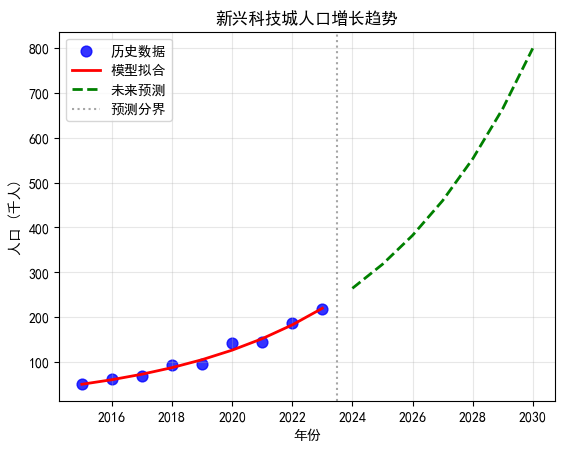

In [8]:
# 7. 可视化分析
plt.scatter(data['year'], data['population']/1000, color='blue', s=60, alpha=0.8, label='历史数据')
plt.plot(data['year'], predicted_population/1000, 'r-', linewidth=2, label='模型拟合')
plt.plot(future_data['year'], future_data['predicted_population']/1000, 'g--', 
         linewidth=2, label='未来预测')
plt.axvline(x=2023.5, color='gray', linestyle=':', alpha=0.7, label='预测分界')
plt.xlabel('年份')
plt.ylabel('人口 (千人)')
plt.title('新兴科技城人口增长趋势')
plt.legend()
plt.grid(True, alpha=0.3)

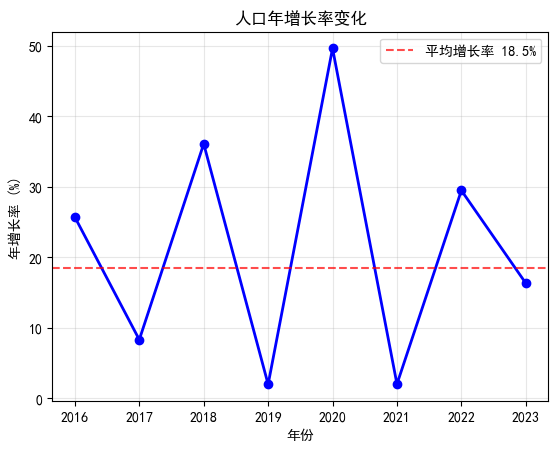

In [9]:
# 7.2 增长率分析
annual_growth_rate = np.diff(data['population']) / data['population'][:-1] * 100
plt.plot(data['year'][1:], annual_growth_rate, 'b-o', linewidth=2, markersize=6)
plt.axhline(y=r_fitted*100, color='red', linestyle='--', alpha=0.7, 
            label=f'平均增长率 {r_fitted*100:.1f}%')
plt.xlabel('年份')
plt.ylabel('年增长率 (%)')
plt.title('人口年增长率变化')
plt.legend()
plt.grid(True, alpha=0.3)



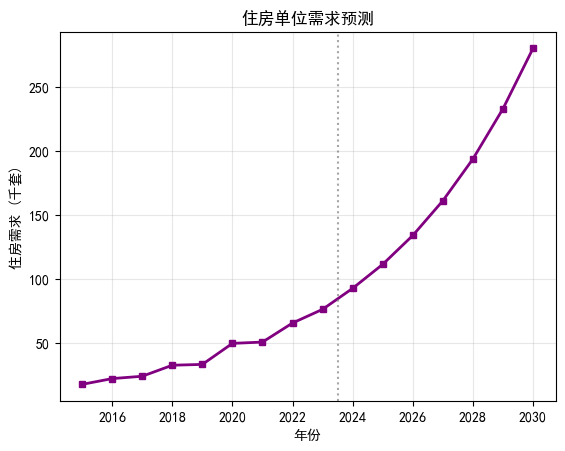

In [10]:
# 7.3 住房需求预测
plt.plot(infrastructure_needs['year'], infrastructure_needs['housing_units']/1000, 
         'purple', linewidth=2, marker='s', markersize=5)
plt.axvline(x=2023.5, color='gray', linestyle=':', alpha=0.7)
plt.xlabel('年份')
plt.ylabel('住房需求 (千套)')
plt.title('住房单位需求预测')
plt.grid(True, alpha=0.3)

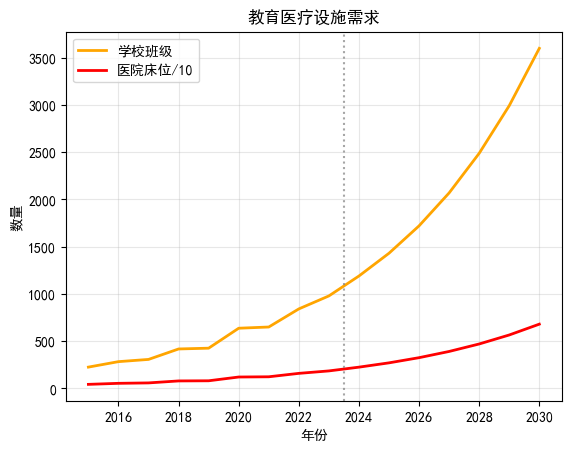

In [11]:
# 7.4 教育医疗需求
plt.plot(infrastructure_needs['year'], infrastructure_needs['school_classes'], 
         'orange', linewidth=2, label='学校班级')
plt.plot(infrastructure_needs['year'], infrastructure_needs['hospital_beds']/10, 
         'red', linewidth=2, label='医院床位/10')
plt.axvline(x=2023.5, color='gray', linestyle=':', alpha=0.7)
plt.xlabel('年份')
plt.ylabel('数量')
plt.title('教育医疗设施需求')
plt.legend()
plt.grid(True, alpha=0.3)



Text(0.5, 1.0, '变量相关性分析')

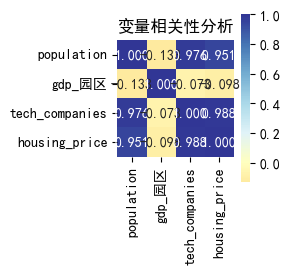

In [12]:
# 7.5 相关性分析热力图
ax5 = plt.subplot(2, 3, 5)
correlation_data = data[['population', 'gdp_园区', 'tech_companies', 'housing_price']]
corr_matrix = correlation_data.corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu', center=0, square=True, fmt='.3f')
plt.title('变量相关性分析')

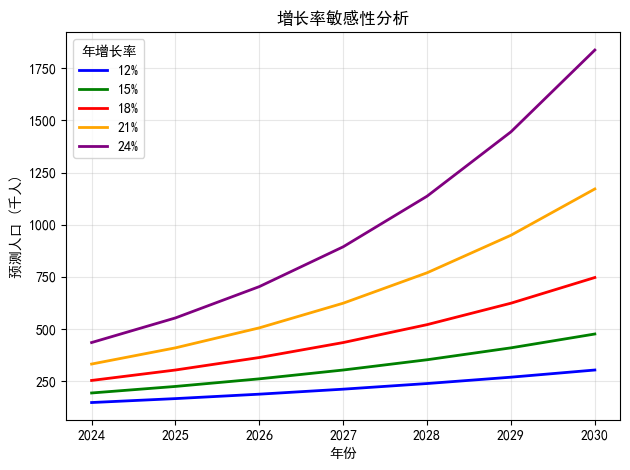

In [13]:
# 7.6 敏感性分析
sensitivity_rates = [0.12, 0.15, 0.18, 0.21, 0.24]  # 不同增长率情景
colors = ['blue', 'green', 'red', 'orange', 'purple']

for i, rate in enumerate(sensitivity_rates):
    sensitive_prediction = exponential_growth(future_time_index, P0_fitted, rate)
    plt.plot(future_data['year'], sensitive_prediction/1000, 
             color=colors[i], linewidth=2, label=f'{rate*100:.0f}%')

plt.xlabel('年份')
plt.ylabel('预测人口 (千人)')
plt.title('增长率敏感性分析')
plt.legend(title='年增长率', loc='upper left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# 8. 风险分析和建议
print(f"\n⚠️ 风险分析:")
print(f"1. 高增长风险: 当前{r_fitted*100:.1f}%的年增长率可能难以长期维持")
print(f"2. 基础设施压力: 2030年需新增住房{infrastructure_needs.iloc[-1]['housing_units'] - infrastructure_needs.iloc[8]['housing_units']:,.0f}套")
print(f"3. 资源约束: 土地供应、环境容量可能成为制约因素")

print(f"\n💡 规划建议:")
print(f"1. 分阶段建设: 按照人口增长节奏合理安排基础设施投资")
print(f"2. 弹性规划: 预留15-20%的设施容量余量应对不确定性")
print(f"3. 智慧城市: 利用科技手段提高城市运行效率")
print(f"4. 产城融合: 平衡就业与居住,减少通勤压力")

# 9. 分期建设计划
print(f"\n🏗️ 建议的分期建设计划:")
periods = [
    ('2024-2025', '第一期', '完善基础交通和住房'),
    ('2026-2027', '第二期', '扩建教育医疗设施'), 
    ('2028-2030', '第三期', '完善商业和生活配套')
]

for period, phase, focus in periods:
    pop_start = future_data[future_data['year'] == int(period[:4])]['predicted_population'].iloc[0]
    pop_end = future_data[future_data['year'] == int(period[-4:])]['predicted_population'].iloc[0]
    print(f"{phase} ({period}): 人口 {pop_start/1000:.0f}k → {pop_end/1000:.0f}k, 重点: {focus}")

print(f"\n✅ 指数增长模型分析完成!")
print(f"💼 适用于: 新兴园区、快速发展地区的短中期规划")



⚠️ 风险分析:
1. 高增长风险: 当前18.5%的年增长率可能难以长期维持
2. 基础设施压力: 2030年需新增住房203,716套
3. 资源约束: 土地供应、环境容量可能成为制约因素

💡 规划建议:
1. 分阶段建设: 按照人口增长节奏合理安排基础设施投资
2. 弹性规划: 预留15-20%的设施容量余量应对不确定性
3. 智慧城市: 利用科技手段提高城市运行效率
4. 产城融合: 平衡就业与居住,减少通勤压力

🏗️ 建议的分期建设计划:
第一期 (2024-2025): 人口 264k → 318k, 重点: 完善基础交通和住房
第二期 (2026-2027): 人口 382k → 460k, 重点: 扩建教育医疗设施
第三期 (2028-2030): 人口 553k → 799k, 重点: 完善商业和生活配套

✅ 指数增长模型分析完成!
💼 适用于: 新兴园区、快速发展地区的短中期规划
